In [1]:
# lin alg for microarray data
library(limma)
library(jsonlite)

In [2]:
# load .rds saved datasets into variables
expr <- readRDS("../datasets/rds_files/expression_matrix_train.rds")
clinical <- readRDS("../datasets/rds_files/clinical_metadata_train.rds")

head(expr)
dim(expr)

head(clinical)
tail(clinical)
dim(clinical)

,gene_symbol,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,⋯,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,5.061765,5.384287,5.462018,5.104647,4.940101,5.087535,5.647719,5.502169,4.935021,⋯,5.612234,5.074677,6.872525,8.020731,5.132484,5.815884,5.310448,5.293781,5.683640,5.880834
2,A1BG-AS1,4.213439,4.497735,5.442854,4.142935,3.836375,3.840813,4.108047,4.117811,4.374573,⋯,5.274847,4.386748,5.158049,4.650182,4.528774,4.627988,4.577176,4.533182,4.283014,4.635586
3,A1CF,2.960794,3.844863,3.603847,3.710878,2.919968,3.246907,2.954523,3.181512,3.115969,⋯,3.695726,3.247118,3.037334,3.657515,3.350718,2.967194,2.943969,3.404410,3.238819,2.898562
4,A2M,6.814863,6.845371,4.532851,7.000975,7.117619,6.683618,6.839982,7.182724,6.365128,⋯,5.206523,6.804822,6.542975,5.768323,5.881436,6.835486,6.455288,6.328355,6.584059,6.576534
5,A2M-AS1,4.973031,4.252506,3.920574,4.064233,5.378826,5.553602,5.198546,5.391066,5.675315,⋯,3.974318,4.694706,4.407413,3.791085,3.544270,4.649494,3.700493,3.785728,3.637337,4.267453
6,A2ML1,3.133812,3.408455,3.779359,3.546180,3.138060,3.030034,3.338255,3.241485,3.111028,⋯,4.034024,3.141456,3.195094,3.162890,3.291446,2.894613,2.764031,3.472512,3.094196,3.243091


[1] 21655   122

,sample_id,is_tumor,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
GSM1045191,GSM1045191,0,NA,NA,NA,NA,NA,NA,NA
GSM1045192,GSM1045192,0,NA,NA,NA,NA,NA,NA,NA
GSM1045193,GSM1045193,0,NA,NA,NA,NA,NA,NA,NA
GSM1045194,GSM1045194,0,NA,NA,NA,NA,NA,NA,NA
GSM1045195,GSM1045195,0,NA,NA,NA,NA,NA,NA,NA
GSM1045196,GSM1045196,0,NA,NA,NA,NA,NA,NA,NA


,sample_id,is_tumor,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
GSM1045306,GSM1045306,1,60,3,6,0,1,1,634
GSM1045307,GSM1045307,1,46,2,2,1,1,0,2952
GSM1045308,GSM1045308,1,47,1,3,NA,1,1,1209
GSM1045309,GSM1045309,1,48,2,3,1,1,0,2105
GSM1045310,GSM1045310,1,70,2,2,1,1,1,639
GSM1045311,GSM1045311,1,62,2,1,1,1,0,2962


[1] 121   9

In [3]:
# create an array of each sample's tissue type to be mapped to design matrix
groups <- factor(clinical$is_tumor)
levels(groups)

# create design matrix and label columns
design <- model.matrix(~ 0 + groups)
colnames(design) <- c("tumor", "normal")

head(design)
tail(design)

[1] "0" "1"

,tumor,normal
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0


,tumor,normal
116,0,1
117,0,1
118,0,1
119,0,1
120,0,1
121,0,1


In [4]:
# define contrast matrix (how will be compare tumor vs normal)?
# diff = tumor exp - normal exp
# showing over expression/under expression in a tumor vs normal
# (like control vs experimental)

contrast <- makeContrasts(tumor_vs_normal = tumor - normal, levels = design)
contrast

,tumor_vs_normal
tumor,1
normal,-1


In [5]:
# fit expression matrix to linear model
fit <- lmFit(expr, design)

# computing the contrast
fit_contrast <- contrasts.fit(fit, contrast)

# what does lmFit() do?
#   - t-test is a linear model, it's giving slop formula
#   - this is a cool, interesting way of computing it by
#     fitting a non linear curve to a line
# contrast?
#   - again, to get the difference in expression not just the expression

Converting data.frame to matrix, treating first column as gene IDs.



In [6]:
# find DEGs using bayesian stats
fit_contrast <- eBayes(fit_contrast)

# generate a list of all differentially expressed genes
all_genes <- topTable(fit_contrast, number = Inf, adjust = "BH")
dim(all_genes)

# filter out for all significant DEGs
deg_genes <- all_genes[
  all_genes$P.Value < 0.05 &
    all_genes$adj.P.Val < 0.05 &
    abs(all_genes$logFC) > 1,
]
dim(deg_genes)
head(deg_genes)

# make dataframe into list of gene symbols
deg_genes_list <- deg_genes$gene_symbol

# eBayes
#   - moderated t: shrinks standard error using empirical Bayes
#   - moderated f: tests multiple coeffs/conditions
#   - empirical bayes: variance shrink, posterior (shrunken) variance estimate
#   - p-val adjust: Benjamini-Hochberg FDR


[1] 21655     7

[1] 1557    7

,gene_symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10959,LOC284825,3.529673,3.781575,22.30632,7.904608e-45,1.711743e-40,91.37392
19330,TMEM132C,2.881126,5.439432,20.66452,1.265697e-41,1.370433e-37,84.12062
212,ACADL,2.997806,3.668408,20.17125,1.239943e-40,8.950324e-37,81.87387
279,ACSM5,2.490258,4.296128,20.01519,2.568701e-40,1.390630e-36,81.15648
7774,HSPB7,1.680985,4.263000,19.76829,8.182186e-40,3.522458e-36,80.01503
13932,PDE3B,3.370559,4.067125,19.72585,9.992881e-40,3.522458e-36,79.81803


Warning message:
"package 'ggrepel' was built under R version 4.5.3"


Saved: volcano_plot.png


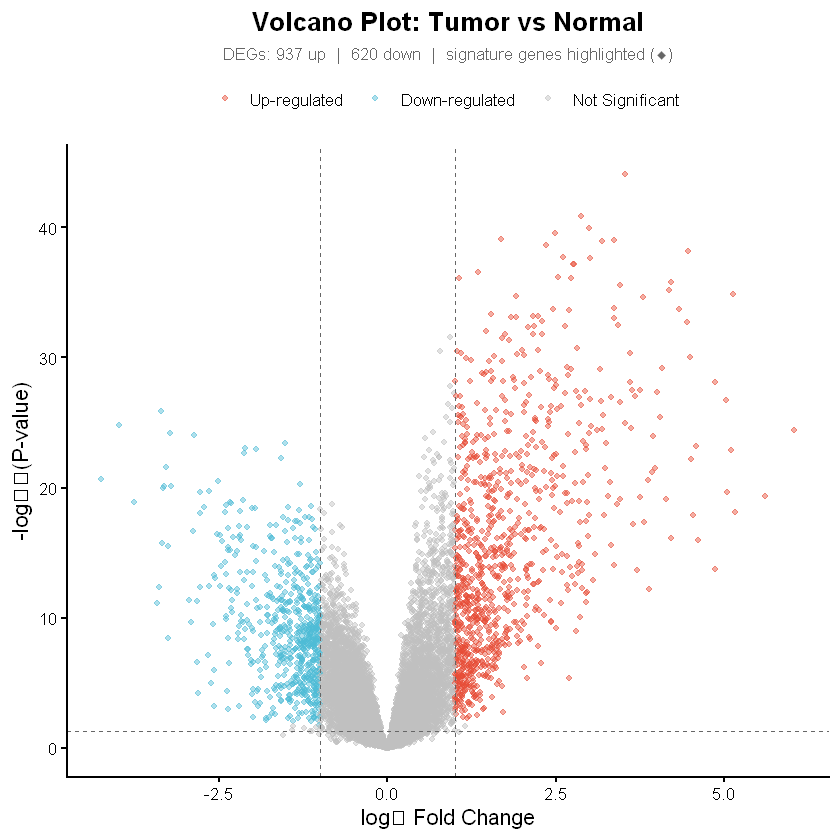

In [7]:
library(ggplot2)
library(ggrepel)

signature_genes <- c("TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1")

# Build plot dataframe from all_genes
volcano_df <- all_genes
volcano_df$neg_log_p <- -log10(volcano_df$P.Value)

# Colour category
volcano_df$category <- "Not Significant"
volcano_df$category[volcano_df$adj.P.Val < 0.05 & volcano_df$logFC >  1] <- "Up-regulated"
volcano_df$category[volcano_df$adj.P.Val < 0.05 & volcano_df$logFC < -1] <- "Down-regulated"
volcano_df$category <- factor(volcano_df$category,
                               levels = c("Up-regulated", "Down-regulated", "Not Significant"))

# Flag signature genes
volcano_df$is_sig <- volcano_df$gene_symbol %in% signature_genes
sig_points <- subset(volcano_df, is_sig)

p <- ggplot(volcano_df, aes(x = logFC, y = neg_log_p, color = category)) +
  # background points
  geom_point(alpha = 0.45, size = 1.2) +
  # threshold lines
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", colour = "grey40", linewidth = 0.4) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", colour = "grey40", linewidth = 0.4) +
  scale_color_manual(values = c(
    "Up-regulated"    = "#E64B35",
    "Down-regulated"  = "#4DBBD5",
    "Not Significant" = "grey75"
  )) +
  labs(
    title    = "Volcano Plot: Tumor vs Normal",
    subtitle = sprintf("DEGs: %d up  |  %d down  |  signature genes highlighted (◆)",
                       sum(volcano_df$category == "Up-regulated"),
                       sum(volcano_df$category == "Down-regulated")),
    x        = "log\u2082 Fold Change",
    y        = "-log\u2081\u2080(P-value)",
    color    = NULL
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, size = 10, color = "grey40"),
    legend.position = "top"
  )

print(p)
ggsave("../visuals/volcano_plot.png", p, width = 8, height = 6, dpi = 150)
cat("Saved: volcano_plot.png\n")

agg_record_112861314 
                   2

Saved: deg_heatmap.png


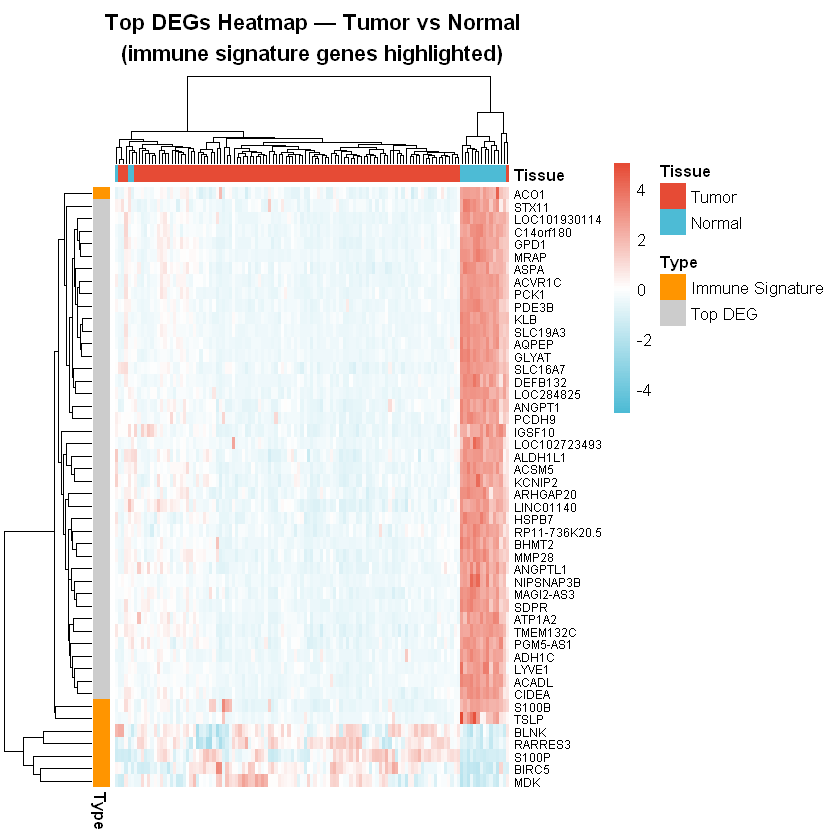

In [8]:
library(pheatmap)

# Top 40 DEGs by adjusted p-value, then union with signature genes
top40_genes   <- head(deg_genes[order(deg_genes$adj.P.Val), ], 40)$gene_symbol
heatmap_genes <- unique(c(top40_genes, signature_genes))
heatmap_genes <- heatmap_genes[heatmap_genes %in% expr$gene_symbol]

# Extract and scale expression matrix
heatmap_expr  <- expr[expr$gene_symbol %in% heatmap_genes, ]
heatmap_mat   <- as.matrix(heatmap_expr[, -1])        # drop gene_symbol column
rownames(heatmap_mat) <- heatmap_expr$gene_symbol

# Column annotation: tumor vs normal
col_annot <- data.frame(
  Tissue = ifelse(clinical$is_tumor == 1, "Tumor", "Normal"),
  row.names = clinical$sample_id
)

# Row annotation: mark the signature genes
row_annot <- data.frame(
  Type = ifelse(rownames(heatmap_mat) %in% signature_genes, "Immune Signature", "Top DEG"),
  row.names = rownames(heatmap_mat)
)

annot_colors <- list(
  Tissue = c(Tumor  = "#E64B35", Normal = "#4DBBD5"),
  Type   = c("Immune Signature" = "#FF9500", "Top DEG" = "grey80")
)

# Render inline (no filename) and capture for saving
p_heat <- pheatmap(
  heatmap_mat,
  scale            = "row",
  color            = colorRampPalette(c("#4DBBD5", "white", "#E64B35"))(100),
  annotation_col   = col_annot,
  annotation_row   = row_annot,
  annotation_colors = annot_colors,
  show_colnames    = FALSE,
  fontsize_row     = 7,
  border_color     = NA,
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  main             = "Top DEGs Heatmap \u2014 Tumor vs Normal\n(immune signature genes highlighted)"
)

# Save to file using the captured gtable
png("../visuals/deg_heatmap.png", width = 10 * 150, height = 10 * 150, res = 150)
grid::grid.newpage()
grid::grid.draw(p_heat$gtable)
dev.off()
cat("Saved: deg_heatmap.png\n")

In [9]:
# download all immune genes
immune_data <- fromJSON("../data/immune_genes.json")

# explore structure
str(immune_data)

'data.frame':	153 obs. of  5 variables:
 $ name  : chr  "Activation of innate immune response" "Adaptive immune memory response" "Adaptive immune memory response involving T cells and B cells" "Adaptive immune response based on somatic recombination of immune receptors built from immunoglobulin superfamily domains" ...
 $ id    : chr  "GO:0002218" "GO:0090716" "GO:0090717" "GO:0002460" ...
 $ source: chr  "GO" "GO" "GO" "GO" ...
 $ link  : chr  "https://amigo.geneontology.org/amigo/term/GO:0002218" "https://amigo.geneontology.org/amigo/term/GO:0090716" "https://amigo.geneontology.org/amigo/term/GO:0090717" "https://amigo.geneontology.org/amigo/term/GO:0002460" ...
 $ count : chr  "164" "3" "3" "162" ...


In [10]:
# extract a list of ALL immune genes

# url used by immport to download Go and Reactome gene data
base_url <- "https://s3.immport.org/release/genelists/current/"
immune_genes <- list()

for (i in seq_len(nrow(immune_data))) {
  id <- immune_data$id[i]
  url <- paste0(base_url, id, ".json")

  # try to read JSON & skip if not available
  try({
    json_data <- fromJSON(url)
    gene_symbol = json_data$genes$Symbol
    if (!is.null(gene_symbol)) {
      immune_genes[[id]] <- gene_symbol
    }
  }, silent = TRUE)
}

# flatten into a single unique vector containing a list of all immune genes
immune_genes <- unique(unlist(immune_genes))

# manually add 8 genes from the signature to the dataset
signature_genes <- c("TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1")
immune_genes <- unique(c(immune_genes, signature_genes))
length(immune_genes)

[1] 3120

In [11]:
# read in files cancer genes and transcription factors
tf_df <- read.csv("../data/transcription_factors.csv")

# extract list of tumor related transcription factors
tumor_tf <- tf_df$Target_Gene

length(tumor_tf)

[1] 9396

In [12]:
# filter for immune and tumor related transcription factors
immune_deg_genes <- intersect(deg_genes_list, immune_genes)
tumor_tf_deg_genes <- intersect(deg_genes_list, tumor_tf)

length(immune_deg_genes)
length(tumor_tf_deg_genes)

# filter dataframe to only include separate immune & tumor tf genes
immune_deg_genes <- deg_genes[deg_genes$gene_symbol %in% immune_deg_genes, ]
tumor_tf_deg_genes <- deg_genes[deg_genes$gene_symbol %in% tumor_tf_deg_genes, ]

dim(immune_deg_genes)
dim(tumor_tf_deg_genes)

[1] 263

[1] 327

[1] 263   7

[1] 327   7

In [13]:
# filter expression matrix to only contain DEGs
filtered_expr <- expr[expr$gene_symbol %in% immune_deg_genes$gene_symbol, ]

all(signature_genes %in% filtered_expr$gene_symbol)
dim(filtered_expr)
head(filtered_expr)

[1] TRUE

[1] 263 122

gene_symbol,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,⋯,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACO1,6.697765,5.872591,4.704279,4.650540,8.647494,7.282538,7.328470,7.406284,7.274613,⋯,4.834910,4.861230,5.020064,5.109236,4.950030,5.203403,5.127605,5.042086,4.999178,4.704057
ADAR,9.719198,9.678302,10.457587,9.122421,10.151534,9.646842,9.593111,10.139440,9.637897,⋯,9.233674,11.423775,10.868326,10.914401,10.483435,10.959269,11.360866,11.477019,11.684356,11.372424
ADIPOQ,11.876584,7.153605,5.392332,5.247072,12.136559,11.837879,11.796036,11.818772,11.989180,⋯,4.036392,6.931453,5.416256,3.628784,4.931670,8.702324,7.397231,7.884212,7.978151,9.344512
AGPAT2,8.604980,6.503194,6.142293,6.581231,9.370264,9.751150,9.549342,9.669911,10.142291,⋯,7.143642,6.424058,6.108297,6.730180,6.958738,7.041712,6.544511,6.754487,6.882038,6.969142
ALDOC,8.414169,4.581926,6.235045,6.079837,8.294877,9.426256,9.651163,9.592635,8.956805,⋯,5.722787,5.520265,4.939628,5.383429,5.833215,5.648214,4.872048,5.677034,6.395405,7.071158
ANG,7.941133,4.814703,4.186915,5.460042,8.182388,8.800447,8.206648,7.718343,8.380673,⋯,3.469765,5.928503,5.623855,7.096097,5.529430,6.406124,5.745155,5.703791,7.028010,6.710324


In [14]:
# transpose expr for cox regression models
expr_transposed <- as.data.frame(t(filtered_expr))

# remove gene_symbol row and set as colnames
colnames(expr_transposed) <- filtered_expr$gene_symbol
expr_transposed <- expr_transposed[-1, ]

head(expr_transposed)

,ACO1,ADAR,ADIPOQ,AGPAT2,ALDOC,ANG,ANGPT1,ANXA1,AP1M2,APOB,⋯,UBE2S,VAMP3,VAMP8,VAV3,VIM,VSIG4,VTCN1,WASF3,XG,ZBTB16
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM1045191,6.697765,9.719198,11.876584,8.604980,8.414169,7.941133,6.564200,9.817748,5.556355,3.744236,⋯,4.445544,8.155041,7.942988,4.577871,10.001357,7.563904,6.866327,9.021858,4.897770,8.081731
GSM1045192,5.872591,9.678302,7.153605,6.503194,4.581926,4.814703,3.905613,7.074081,5.120402,3.504122,⋯,4.422642,7.358038,9.970144,4.369697,8.650840,7.693408,4.912463,4.480019,3.334647,4.078880
GSM1045193,4.704279,10.457587,5.392332,6.142293,6.235045,4.186915,3.946060,4.031208,4.889919,3.106630,⋯,4.878597,6.282494,8.971080,4.458827,7.124404,5.279563,4.479120,4.514484,3.458176,4.305987
GSM1045194,4.650540,9.122421,5.247072,6.581231,6.079837,5.460042,4.049906,6.102090,6.759978,2.911336,⋯,4.498002,6.274657,8.636839,5.733220,7.628729,4.990067,7.731202,5.544438,3.338516,5.512143
GSM1045195,8.647494,10.151534,12.136559,9.370264,8.294877,8.182388,6.256205,10.263854,4.763354,4.801098,⋯,4.847608,8.498974,7.105619,4.054034,10.257068,7.878502,6.027630,8.935739,6.005618,7.841789
GSM1045196,7.282538,9.646842,11.837879,9.751150,9.426256,8.800447,6.359753,10.476237,4.520120,4.803490,⋯,4.726844,8.777373,7.352073,3.698480,10.376463,8.828870,3.852591,9.598782,5.609578,9.044752


In [15]:
# create datasets directory if it doesn't exist
dir.create("../datasets/rds_files", recursive = TRUE, showWarnings = FALSE)
dir.create("../datasets/csv_files", recursive = TRUE, showWarnings = FALSE)

# save datasets in datasets folder for persistent storage
saveRDS(deg_genes, "../datasets/rds_files/deg_train.rds")
saveRDS(expr_transposed, "../datasets/rds_files/deg_expression_matrix_train.rds")

# write datasets to csv for python use
write.csv(deg_genes, "../datasets/csv_files/deg_train.csv")
write.csv(expr_transposed, "../datasets/csv_files/deg_expression_matrix_train.csv")
write.csv(clinical, "../datasets/csv_files/clinical_metadata_train.csv")